# 📊 Visual Analysis of U.S. Monetary Policy

## 🧠 Introduction

Monetary policy plays a central role in shaping inflation, labor market conditions, and overall economic stability. The Federal Funds Rate is one of the Federal Reserve’s primary tools for influencing borrowing costs and managing macroeconomic conditions.

This notebook focuses on the **visual analysis and interpretation** of the Federal Funds Rate alongside key economic indicators, including **inflation** and **unemployment**. Rather than emphasizing raw data preparation, this notebook is designed to communicate the analytical story through charts and concise interpretation.

By examining long-term trends and variable relationships, this analysis highlights how monetary policy changes over time and how interest rate decisions interact with broader economic conditions.

## 🎯 Analytical Objective

The goal of this notebook is to visually analyze how the Federal Funds Rate has evolved over time and how it relates to inflation and unemployment across different macroeconomic environments.

## 📂 Load and Prepare Data

This analysis uses a cleaned macroeconomic dataset containing the Federal Funds Rate, CPI, unemployment, and year-over-year inflation.

Before visualization, the data is prepared by:
- converting the date field into a datetime format,
- sorting observations chronologically,
- cleaning percentage-based inflation values,
- and creating rolling averages to smooth short-term volatility.

This preparation step ensures that the charts focus on meaningful long-run trends rather than formatting issues or monthly noise.

## 💼 Why This Analysis Matters

Interest rate decisions affect more than monetary policy headlines. They shape borrowing costs, investment conditions, consumer demand, and broader market expectations.

By analyzing the Federal Funds Rate together with inflation and unemployment, this notebook provides a more business-relevant view of monetary policy than a single-variable time-series approach alone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/macro_dashboard_clean.csv")

# Convert and sort dates
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").copy()

# Clean Inflation YoY (remove % and convert to numeric)
df["Inflation YoY"] = (
    df["Inflation YoY"]
    .astype(str)
    .str.replace("%", "", regex=False)
)
df["Inflation YoY"] = pd.to_numeric(df["Inflation YoY"], errors="coerce")

# Create additional fields
df["Fed Rate Change"] = df["Fed Rate"].diff()
df["Fed Rate Rolling"] = df["Fed Rate"].rolling(window=12).mean()
df["Inflation Rolling"] = df["Inflation YoY"].rolling(window=12).mean()
df["Unemployment Rolling"] = df["Unemployment"].rolling(window=12).mean()

# Optional recent subset for modern trends
recent_df = df[df["Date"] >= "2000-01-01"].copy()

# General plotting style
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Quick check
df[["Date", "Fed Rate", "Inflation YoY", "Unemployment"]].head()

,Date,Fed Rate,Inflation YoY,Unemployment
0,1954-07-01,0.80,NaN,5.8
1,1954-08-01,1.22,NaN,6.0
2,1954-09-01,1.07,NaN,6.1
3,1954-10-01,0.85,NaN,5.7
4,1954-11-01,0.83,NaN,5.3


In [2]:
# Chart annotation function
# Main event sets
event_dates_full = {
    "Volcker Tightening": "1979-10-01",
    "1987 Market Crash": "1987-10-01",
    "2001 Recession": "2001-03-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID Shock": "2020-03-01",
    "2022 Rate Hikes": "2022-03-01"
}

event_dates_recent = {
    "2001 Recession": "2001-03-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID Shock": "2020-03-01",
    "2022 Rate Hikes": "2022-03-01"
}

def add_event_annotations(ax, event_dict, fontsize=9):
    """
    Add vertical event lines and staggered labels above the chart area.
    Labels are positioned in axis coordinates to avoid sitting on the data.
    """
    y_positions = [0.98, 0.92, 0.86, 0.80]  # stagger labels vertically

    for i, (label, date) in enumerate(event_dict.items()):
        event_date = pd.to_datetime(date)

        # vertical line
        ax.axvline(event_date, linestyle="--", alpha=0.35, color="gray", linewidth=1)

        # stagger label positions
        y_pos = y_positions[i % len(y_positions)]

        # place label using x in data coordinates, y in axis coordinates
        ax.text(
            event_date,
            y_pos,
            label,
            transform=ax.get_xaxis_transform(),
            fontsize=fontsize,
            ha="center",
            va="top",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                boxstyle="round,pad=0.2"
            ),
            clip_on=False
        )

## 📈 Visual Analysis of Monetary Policy Trends

With the data prepared, the next section examines how the Federal Funds Rate has evolved over time and how it relates to inflation and unemployment.

The charts are designed to move from broad historical context to more specific macroeconomic relationships, allowing the analysis to build logically from overall policy behavior to variable interaction.

## 📈 Chart 1: Federal Funds Rate Over Time

This chart provides a long-run view of the Federal Funds Rate and establishes the policy context for the rest of the analysis. Event annotations highlight major economic periods that shaped monetary policy responses across decades.

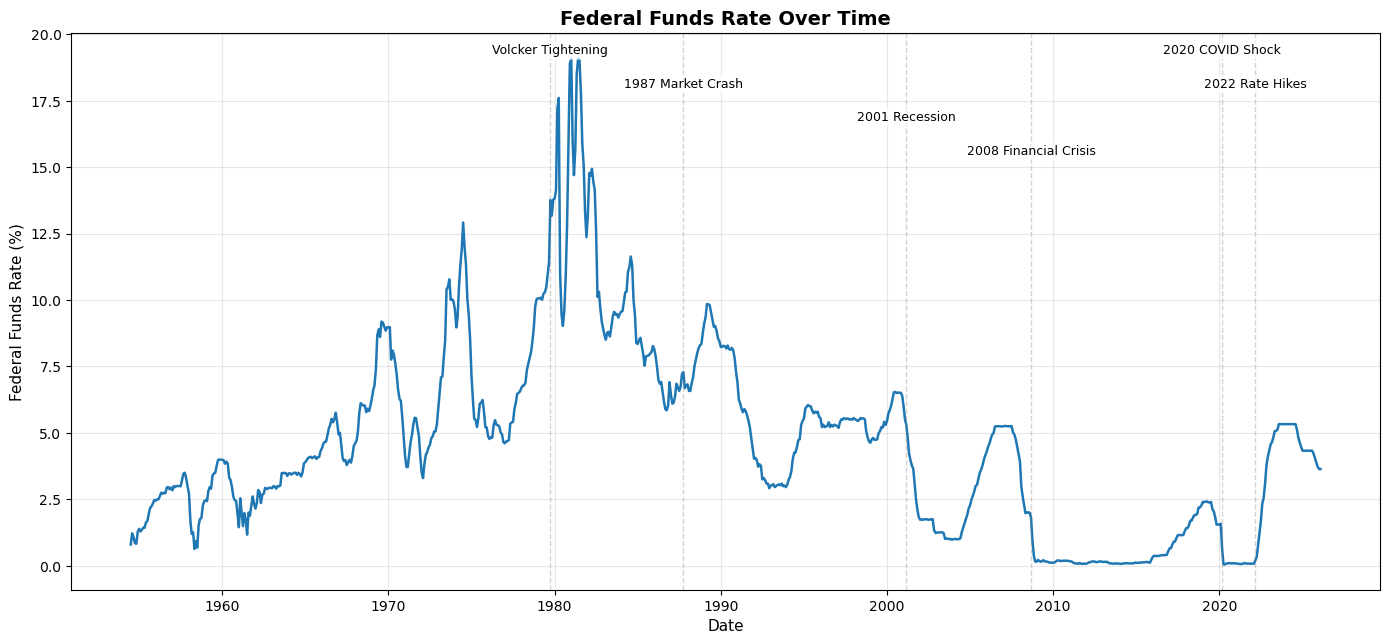

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df["Date"], df["Fed Rate"], linewidth=1.8)

add_event_annotations(ax, event_dates_full)

ax.set_title("Federal Funds Rate Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Federal Funds Rate (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("images/rate_levels_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

### 📊 Interpretation

The Federal Funds Rate moves through clear long-run policy regimes rather than following a stable pattern over time. Higher-rate environments generally align with periods of inflationary pressure, while lower-rate environments reflect accommodative policy during economic stress or recovery.

Event annotations add context by linking major shifts in the rate environment to recognizable economic disruptions. This makes the chart more useful as a storytelling device because it connects monetary policy changes to real-world economic events rather than showing the rate series in isolation.

## 📉 Chart 2: Inflation and the Federal Funds Rate

Inflation is one of the Federal Reserve’s most important policy considerations. This chart compares inflation with the Federal Funds Rate to show how tighter monetary policy often emerges in higher-inflation environments.

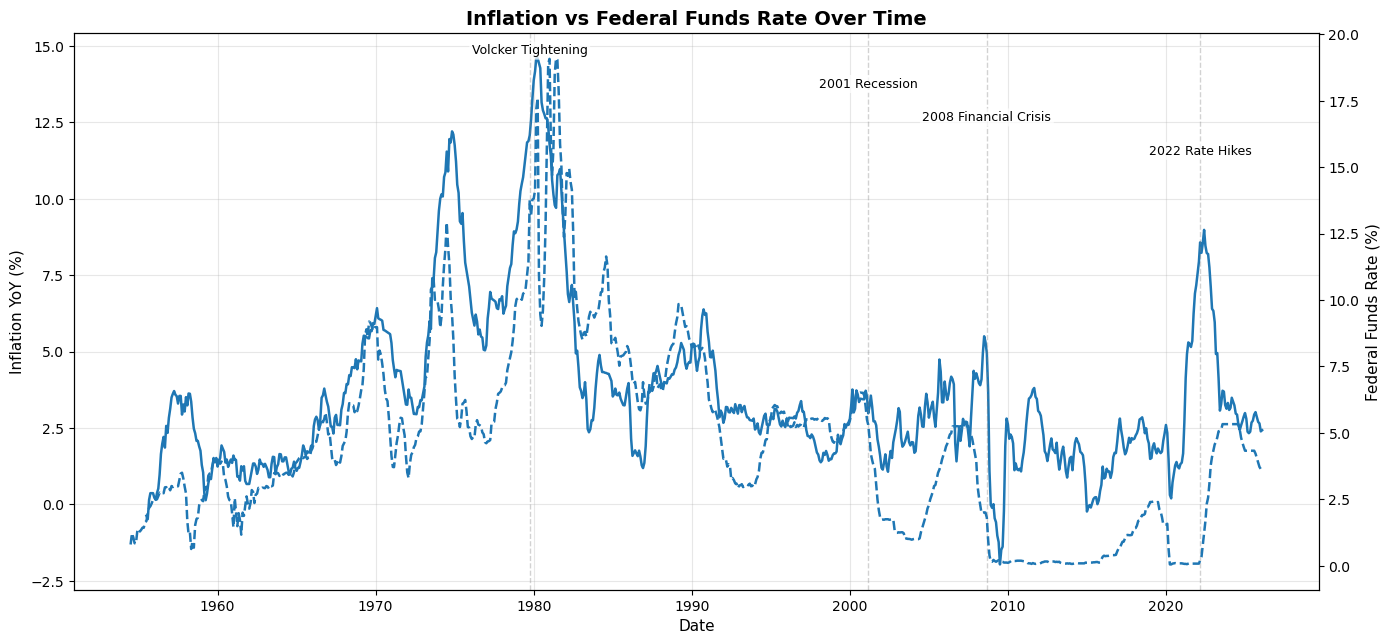

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(df["Date"], df["Inflation YoY"], linewidth=1.8)
ax1.set_xlabel("Date")
ax1.set_ylabel("Inflation YoY (%)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Fed Rate"], linestyle="--", linewidth=1.8)
ax2.set_ylabel("Federal Funds Rate (%)")

# Use fewer events here to reduce crowding
inflation_events = {
    "Volcker Tightening": "1979-10-01",
    "2001 Recession": "2001-03-01",
    "2008 Financial Crisis": "2008-09-01",
    "2022 Rate Hikes": "2022-03-01"
}

add_event_annotations(ax1, inflation_events)

plt.title("Inflation vs Federal Funds Rate Over Time")
fig.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("images/inflation_vs_fed_rate.png", dpi=300, bbox_inches="tight")
plt.show()

### 📊 Interpretation

The relationship between inflation and the Federal Funds Rate suggests that tighter monetary policy often emerges during higher-inflation environments. When price pressure rises, the Federal Reserve is more likely to increase rates in an effort to stabilize inflation.

However, the relationship is not perfectly synchronized. The chart shows that policy responses can lag or vary in intensity depending on broader economic conditions. This reinforces the idea that inflation is central to policy decisions, but not the only factor shaping them.

## 👩‍💼 Chart 3: Unemployment and the Federal Funds Rate

The Federal Reserve’s policy decisions are shaped not only by inflation, but also by labor market conditions. This chart compares unemployment with the Federal Funds Rate to illustrate how monetary policy shifts across stronger and weaker economic environments.

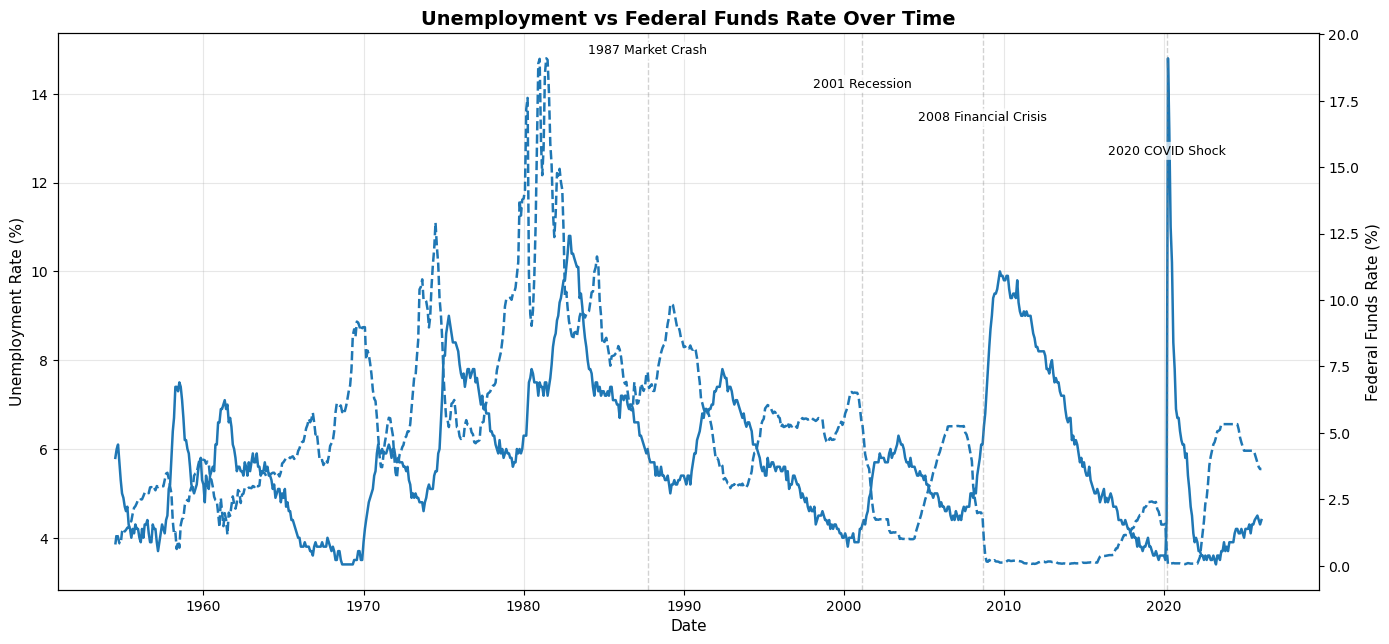

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(df["Date"], df["Unemployment"], linewidth=1.8)
ax1.set_xlabel("Date")
ax1.set_ylabel("Unemployment Rate (%)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Fed Rate"], linestyle="--", linewidth=1.8)
ax2.set_ylabel("Federal Funds Rate (%)")

unemployment_events = {
    "1987 Market Crash": "1987-10-01",
    "2001 Recession": "2001-03-01",
    "2008 Financial Crisis": "2008-09-01",
    "2020 COVID Shock": "2020-03-01"
}

add_event_annotations(ax1, unemployment_events)

plt.title("Unemployment vs Federal Funds Rate Over Time")
fig.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("images/unemployment_vs_fed_rate.png", dpi=300, bbox_inches="tight")
plt.show()

### 📊 Interpretation

This chart highlights the policy trade-offs associated with labor market conditions. Higher unemployment often aligns with lower-rate environments, suggesting accommodative policy during periods of economic weakness.

At the same time, the chart also shows that monetary policy is not solely driven by unemployment. The Federal Reserve balances labor market conditions with inflation and broader macroeconomic risk, which helps explain why the relationship is directional but not purely mechanical.

## 🔍 Chart 4: Recent Macroeconomic Trends Since 2000

A focused view of the modern period makes recent monetary policy behavior easier to interpret. Using 12-month rolling averages reduces short-term volatility and highlights how inflation, unemployment, and interest rates evolved together across major economic events.

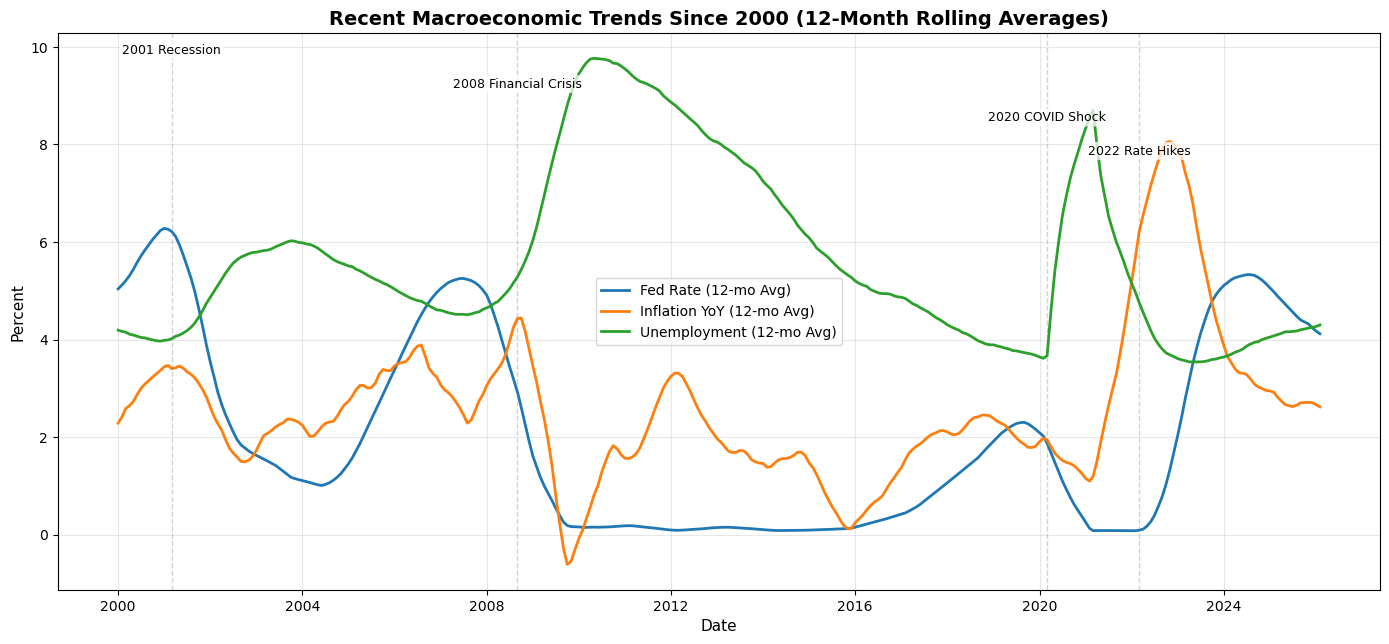

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    recent_df["Date"],
    recent_df["Fed Rate Rolling"],
    linewidth=2,
    label="Fed Rate (12-mo Avg)"
)

ax.plot(
    recent_df["Date"],
    recent_df["Inflation Rolling"],
    linewidth=2,
    label="Inflation YoY (12-mo Avg)"
)

ax.plot(
    recent_df["Date"],
    recent_df["Unemployment Rolling"],
    linewidth=2,
    label="Unemployment (12-mo Avg)"
)

add_event_annotations(ax, event_dates_recent)

ax.set_title("Recent Macroeconomic Trends Since 2000 (12-Month Rolling Averages)")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("images/recent_macro_trends.png", dpi=300, bbox_inches="tight")
plt.show()

### 📊 Interpretation

Focusing on the post-2000 period makes recent monetary policy behavior easier to interpret. Rolling averages smooth short-term volatility and reveal longer-run interactions among inflation, unemployment, and interest rates.

This chart highlights prolonged low-rate environments following major economic disruptions, followed by policy normalization as inflation and labor market conditions changed. It provides the clearest modern view of how monetary policy responds within a broader macroeconomic context.

## 📊 Statistical Analysis

The charts in this notebook provide visual evidence of long-run trends and macroeconomic relationships. To strengthen the analysis, the next section quantifies these relationships using correlation analysis and linear regression.

This helps move the notebook from descriptive visualization toward a more rigorous analytical framework.

In [7]:
analysis_df = df[["Fed Rate", "Inflation YoY", "Unemployment"]].dropna()

correlation_matrix = analysis_df.corr()
correlation_matrix

,Fed Rate,Inflation YoY,Unemployment
Fed Rate,1.000000,0.703877,0.059728
Inflation YoY,0.703877,1.000000,0.089357
Unemployment,0.059728,0.089357,1.000000


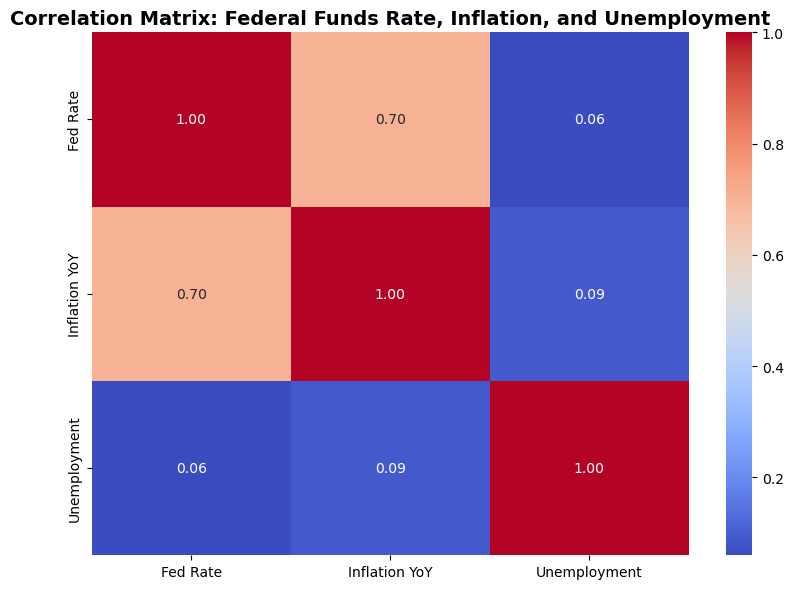

In [8]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Federal Funds Rate, Inflation, and Unemployment")
plt.tight_layout()
plt.show()

### 📊 Interpretation: Correlation Analysis

The correlation matrix provides a high-level view of how the Federal Funds Rate, inflation, and unemployment move relative to one another.

These results help quantify directional relationships observed in the charts. While correlation does not imply causation, it strengthens the analysis by showing whether visual patterns are broadly supported by the data.

In [9]:
import statsmodels.api as sm

reg_df = df[["Fed Rate", "Inflation YoY", "Unemployment"]].dropna().copy()

X = reg_df[["Inflation YoY", "Unemployment"]]
X = sm.add_constant(X)
y = reg_df["Fed Rate"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Fed Rate   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     414.4
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          4.21e-126
Time:                        01:02:14   Log-Likelihood:                -1983.0
No. Observations:                 847   AIC:                             3972.
Df Residuals:                     844   BIC:                             3986.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.4050      0.324      4.331

### 📊 Interpretation: Regression Analysis

The regression model estimates how inflation and unemployment relate to the Federal Funds Rate when evaluated together.

This adds analytical depth by moving beyond visual comparison and into quantified relationships. While the model is intentionally simple and not designed for causal inference, it helps show whether the key macroeconomic variables used in this project have a measurable association with the policy rate.

## 🔍 Key Findings

- The Federal Funds Rate exhibits clear long-run policy regimes, shifting between restrictive and accommodative environments over time.

- Rate changes provide clearer insight into monetary policy actions than rate levels alone, highlighting periods of active intervention and policy transitions.

- Higher inflation environments are often associated with tighter monetary policy, though the relationship is not strictly linear and varies across economic conditions.

- Lower interest rate periods frequently align with weaker labor market conditions, suggesting accommodative policy during periods of economic stress.

- Recent decades show prolonged low-rate environments and more gradual policy adjustments, reflecting shifts in modern monetary policy behavior.

## ⚠️ Limitations

- This analysis is exploratory and does not establish causality between interest rates, inflation, and unemployment.
  
- The relationships observed may be influenced by additional macroeconomic variables not included in the dataset.

- Some early-period inflation values are missing, which limits interpretation in the earliest years.

- Monthly observations may smooth over short-term policy shifts or intra-period decisions.

- The regression model is intentionally simple and should be interpreted as an analytical supplement rather than a full forecasting framework.  

## 🚀 Next Steps

- Expand the feature set to include additional macroeconomic drivers such as wage growth, recession indicators, or market expectations.  
- Apply more advanced models to better quantify policy dynamics and improve forecasting potential.  
- Segment the analysis by policy eras to compare structural differences across monetary regimes.  
- Build an interactive dashboard to support stakeholder exploration of macroeconomic trends.  
- Extend event-based annotation and regime classification to strengthen narrative analysis.  